# Семинар 2. Исследование методов линейной регрессии

#### Критерий оценивания:
#### Пункт 14: максимум 0,5 балла
#### Пункт 15: максимум 0,5 балла

#### Итого за работу: максимум 1 балл
#### P.S. пункты 14 и 15 без пунктов 1-13 не засчитываются, ответы на вопросы из ИИ не засчитываются

1. Загрузите датасет и выведите на экран первые несколько строк

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from threadpoolctl import threadpool_limits

pd.set_option('display.max_columns', 12)
pd.set_option('display.float_format', '{:,.6f}'.format)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

data = pd.read_csv('auto_dataset.csv')
display(data.head())
print(f'Размер датасета: {data.shape}')
print(f'Пропуски: {data.isna().sum().sum()}')
print(f'Полные дубликаты: {data.duplicated().sum()}')
display(data.describe(include='number'))

,brand,model,vehicleType,gearbox,fuelType,notRepairedDamage,powerPS,kilometer,autoAgeMonths,price
0,volkswagen,golf,kleinwagen,manuell,benzin,nein,75,150000,177,1500
1,skoda,fabia,kleinwagen,manuell,diesel,nein,69,90000,93,3600
2,bmw,3er,limousine,manuell,benzin,ja,102,150000,246,650
3,peugeot,2_reihe,cabrio,manuell,benzin,nein,109,150000,140,2200
4,mazda,3_reihe,limousine,manuell,benzin,nein,105,150000,136,2000


Размер датасета: (1000, 10)
Пропуски: 0
Полные дубликаты: 1


,powerPS,kilometer,autoAgeMonths,price
count,"1,000.000000","1,000.000000","1,000.000000","1,000.000000"
mean,134.067000,"123,430.000000",145.088000,"7,065.158000"
std,61.203320,"39,824.880679",76.669358,"7,830.579832"
min,52.000000,"5,000.000000",3.000000,1.000000
25%,90.000000,"100,000.000000",92.000000,"1,900.000000"
50%,122.000000,"150,000.000000",138.000000,"4,500.000000"
75%,163.000000,"150,000.000000",191.000000,"9,299.250000"
max,510.000000,"150,000.000000",579.000000,"56,900.000000"


2. Разбейте выборку на признаки и ответы. Закодируйте категориальные признаки.

In [2]:
X = data.drop(columns='price')
y = data['price'].astype(float)
categorical_columns = X.select_dtypes(include='object').columns.tolist()
numeric_columns = X.select_dtypes(include='number').columns.tolist()

preprocessor = ColumnTransformer([
    ('numeric', StandardScaler(), numeric_columns),
    ('categorical', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_columns)
])

print('Ответ: price')
print('Числовые признаки:', ', '.join(numeric_columns))
print('Категориальные признаки:', ', '.join(categorical_columns))
display(X.head())
display(y.head())

Ответ: price
Числовые признаки: powerPS, kilometer, autoAgeMonths
Категориальные признаки: brand, model, vehicleType, gearbox, fuelType, notRepairedDamage


,brand,model,vehicleType,gearbox,fuelType,notRepairedDamage,powerPS,kilometer,autoAgeMonths
0,volkswagen,golf,kleinwagen,manuell,benzin,nein,75,150000,177
1,skoda,fabia,kleinwagen,manuell,diesel,nein,69,90000,93
2,bmw,3er,limousine,manuell,benzin,ja,102,150000,246
3,peugeot,2_reihe,cabrio,manuell,benzin,nein,109,150000,140
4,mazda,3_reihe,limousine,manuell,benzin,nein,105,150000,136


0   1,500.000000
1   3,600.000000
2     650.000000
3   2,200.000000
4   2,000.000000
Name: price, dtype: float64

Для категорий выбрал one-hot, чтобы не задавать им искусственный порядок. Например, номер марки автомобиля не должен означать, что одна марка «больше» другой. Здесь подготовил кодировщик, а обучаю его в следующем пункте после разбиения, только на train.

3. Разбейте датасет на train val test в отношении 8:1:1

In [3]:
RANDOM_STATE = 42
groups = data.groupby(data.columns.tolist(), sort=False).ngroup()
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_indices, holdout_indices = next(splitter.split(X, y, groups=groups))
holdout = data.iloc[holdout_indices]

splitter = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=RANDOM_STATE)
val_local, test_local = next(splitter.split(holdout, groups=groups.iloc[holdout_indices]))
val_indices = holdout_indices[val_local]
test_indices = holdout_indices[test_local]

X_train_raw, X_val_raw, X_test_raw = [X.iloc[i] for i in (train_indices, val_indices, test_indices)]
y_train, y_val, y_test = [y.iloc[i].to_numpy() for i in (train_indices, val_indices, test_indices)]

X_train = preprocessor.fit_transform(X_train_raw)
X_val = preprocessor.transform(X_val_raw)
X_test = preprocessor.transform(X_test_raw)
X_train = np.column_stack([np.ones(len(X_train)), X_train])
X_val = np.column_stack([np.ones(len(X_val)), X_val])
X_test = np.column_stack([np.ones(len(X_test)), X_test])
feature_names = ['intercept'] + preprocessor.get_feature_names_out().tolist()

target_scaler = StandardScaler()
y_train_scaled = target_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()
y_val_scaled = target_scaler.transform(y_val.reshape(-1, 1)).ravel()
y_mean, y_scale = target_scaler.mean_[0], target_scaler.scale_[0]

assert [len(y_train), len(y_val), len(y_test)] == [800, 100, 100]
for left, right in [(train_indices, val_indices), (train_indices, test_indices), (val_indices, test_indices)]:
    assert set(left).isdisjoint(right)
    assert set(groups.iloc[left]).isdisjoint(groups.iloc[right])
assert len(set(train_indices) | set(val_indices) | set(test_indices)) == len(data)

display(pd.DataFrame({
    'Выборка': ['train', 'val', 'test'],
    'Строк': [len(y_train), len(y_val), len(y_test)],
    'Доля': [len(y_train) / len(data), len(y_val) / len(data), len(y_test) / len(data)],
    'Признаков со свободным членом': [X_train.shape[1], X_val.shape[1], X_test.shape[1]]
}))
for name, matrix, indices in [('train', X_train, train_indices), ('val', X_val, val_indices), ('test', X_test, test_indices)]:
    print(name)
    display(pd.DataFrame(matrix[:5], columns=feature_names, index=indices[:5]))

,Выборка,Строк,Доля,Признаков со свободным членом
0,train,800,0.800000,199
1,val,100,0.100000,199
2,test,100,0.100000,199


train


,intercept,numeric__powerPS,numeric__kilometer,numeric__autoAgeMonths,categorical__brand_alfa_romeo,categorical__brand_audi,...,categorical__fuelType_benzin,categorical__fuelType_diesel,categorical__fuelType_hybrid,categorical__fuelType_lpg,categorical__notRepairedDamage_ja,categorical__notRepairedDamage_nein
0,1.000000,-0.930289,0.672833,0.385049,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
1,1.000000,-1.026565,-0.827212,-0.683119,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
2,1.000000,-0.497046,0.672833,1.262473,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
3,1.000000,-0.384724,0.672833,-0.085453,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
4,1.000000,-0.448908,0.672833,-0.136319,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000


val


,intercept,numeric__powerPS,numeric__kilometer,numeric__autoAgeMonths,categorical__brand_alfa_romeo,categorical__brand_audi,...,categorical__fuelType_benzin,categorical__fuelType_diesel,categorical__fuelType_hybrid,categorical__fuelType_lpg,categorical__notRepairedDamage_ja,categorical__notRepairedDamage_nein
10,1.000000,0.433624,-0.577205,-0.797566,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
23,1.000000,0.706406,0.672833,-0.555956,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
29,1.000000,1.588938,0.672833,-0.021872,0.000000,1.000000,...,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
30,1.000000,-1.170979,-1.327227,-0.950161,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
54,1.000000,-0.127987,0.672833,0.677524,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000


test


,intercept,numeric__powerPS,numeric__kilometer,numeric__autoAgeMonths,categorical__brand_alfa_romeo,categorical__brand_audi,...,categorical__fuelType_benzin,categorical__fuelType_diesel,categorical__fuelType_hybrid,categorical__fuelType_lpg,categorical__notRepairedDamage_ja,categorical__notRepairedDamage_nein
25,1.000000,-0.384724,0.672833,-1.293501,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
39,1.000000,1.139649,-1.077220,-1.051891,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
44,1.000000,-0.737736,0.672833,0.372333,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
59,1.000000,0.722452,0.672833,-0.149035,0.000000,1.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
63,1.000000,-0.898197,0.672833,0.067142,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000


#### Подготовка данных и условия сравнения

Использовал тот же датасет и то же разбиение, что в прошлой работе. В данных есть одна пара одинаковых строк. Разбил их по группам, чтобы копии не оказались в разных выборках. Обе остались в train, размеры получились 800/100/100.

Числовые признаки стандартизировал по train. Категории, которых нет в train, при преобразовании val и test кодируются нулями в своём блоке. Добавил столбец единиц для свободного члена. Цену тоже стандартизировал на время обучения, а прогнозы перед расчётом метрик вернул в исходный масштаб. Поэтому Loss в таблицах и на графиках — MSE исходной цены, без логарифмирования.

Для всех методов задал нулевые начальные веса, `random_state=42`, лимит 10000 обновлений и остановку при норме полного градиента MSE стандартизированной цены не больше $10^{-5}$. Размер батча SGD — 32. Для Momentum взял $\alpha=0.9$, для Adam — $\beta_1=0.9$, $\beta_2=0.999$, $\varepsilon=10^{-8}$. SAG обновляет градиент одного случайного объекта и хранит предыдущие градиенты. Эти настройки не менял при переборе шагов.

Постоянный шаг равен $\eta_k=n$. Для переменного использовал формулу из лекции: $\eta_k=\lambda/\sqrt{1+k}$, где $k=0,1,2,\ldots$. В обоих случаях перебираю $10^{-5},10^{-4},10^{-3},10^{-2},10^{-1},1$. На графиках ошибок используется логарифмическая шкала по вертикали.

Шаг выбираю по Loss_val на последней итерации. По val не обновляю веса и не выбираю момент остановки. Если расчёт переполняется из-за расходимости, помечаю такой запуск отдельно и ставлю ему бесконечную ошибку, чтобы он не участвовал в выборе лучшего шага.

Под «числом итераций на test» в задании понимаю число итераций обучения выбранной модели. На test делаю только прогноз: дополнительного обучения на этой выборке нет.

In [4]:
class ConstantLR:
    def __init__(self, lyamda=0.1):
        self.lyamda = lyamda

    def __call__(self, k):
        return self.lyamda


class TimeDecayLR:
    def __init__(self, lyamda=0.1, s0=1, p=0.5):
        self.lyamda = lyamda
        self.s0 = s0
        self.p = p

    def __call__(self, k):
        return self.lyamda * (self.s0 / (self.s0 + k)) ** self.p


class BaseDescent:
    def __init__(self, lyamda=0.1, schedule='constant', max_iter=10000,
                 tolerance=1e-5, random_state=42):
        if schedule not in ('constant', 'decay'):
            raise ValueError('Неизвестный закон изменения шага')
        self.lyamda = lyamda
        self.schedule = schedule
        self.lr = ConstantLR(lyamda) if schedule == 'constant' else TimeDecayLR(lyamda)
        self.max_iter = max_iter
        self.tolerance = tolerance
        self.random_state = random_state

    def initialize(self, X):
        self.w = np.zeros(X.shape[1])
        self.rng = np.random.default_rng(self.random_state)

    def update(self, X, y, k):
        raise NotImplementedError

    def fit(self, X, y, X_val, y_val, loss_scale=1.0):
        self.initialize(X)
        residual = X @ self.w - y
        self.gradient = 2 * X.T @ residual / len(y)
        self.train_history = [np.mean(residual ** 2) * loss_scale]
        self.val_history = [np.mean((X_val @ self.w - y_val) ** 2) * loss_scale]
        self.n_iter = 0
        self.status = 'Лимит итераций'

        if np.linalg.norm(self.gradient) <= self.tolerance:
            self.status = 'Сходимость'
            return self

        with np.errstate(over='ignore', invalid='ignore'):
            for k in range(self.max_iter):
                self.w += self.update(X, y, k)
                residual = X @ self.w - y
                train_loss = np.mean(residual ** 2) * loss_scale
                val_loss = np.mean((X_val @ self.w - y_val) ** 2) * loss_scale
                self.n_iter = k + 1
                self.train_history.append(train_loss)
                self.val_history.append(val_loss)

                if not np.all(np.isfinite(self.w)) or not np.isfinite(train_loss + val_loss):
                    self.status = 'Расходимость'
                    break

                self.gradient = 2 * X.T @ residual / len(y)
                if np.linalg.norm(self.gradient) <= self.tolerance:
                    self.status = 'Сходимость'
                    break

        return self

    def predict(self, X):
        return X @ self.w


class VanillaGradientDescent(BaseDescent):
    def update(self, X, y, k):
        return -self.lr(k) * self.gradient


class StochasticGradientDescent(BaseDescent):
    def __init__(self, lyamda=0.1, batch_size=32, **kwargs):
        super().__init__(lyamda=lyamda, **kwargs)
        self.batch_size = batch_size

    def update(self, X, y, k):
        indices = self.rng.choice(len(y), size=min(self.batch_size, len(y)), replace=False)
        X_batch, y_batch = X[indices], y[indices]
        gradient = 2 * X_batch.T @ (X_batch @ self.w - y_batch) / len(indices)
        return -self.lr(k) * gradient


class SAGDescent(BaseDescent):
    def initialize(self, X):
        super().initialize(X)
        self.gradient_memory = np.zeros_like(X)
        self.average_gradient = np.zeros(X.shape[1])

    def update(self, X, y, k):
        j = self.rng.integers(len(y))
        new_gradient = 2 * (X[j] @ self.w - y[j]) * X[j]
        self.average_gradient += (new_gradient - self.gradient_memory[j]) / len(y)
        self.gradient_memory[j] = new_gradient
        return -self.lr(k) * self.average_gradient


class MomentumDescent(BaseDescent):
    def __init__(self, lyamda=0.1, alpha=0.9, **kwargs):
        super().__init__(lyamda=lyamda, **kwargs)
        self.alpha = alpha

    def initialize(self, X):
        super().initialize(X)
        self.h = np.zeros(X.shape[1])

    def update(self, X, y, k):
        self.h = self.alpha * self.h + self.lr(k) * self.gradient
        return -self.h


class Adam(BaseDescent):
    def __init__(self, lyamda=0.1, beta1=0.9, beta2=0.999, eps=1e-8, **kwargs):
        super().__init__(lyamda=lyamda, **kwargs)
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps

    def initialize(self, X):
        super().initialize(X)
        self.m = np.zeros(X.shape[1])
        self.v = np.zeros(X.shape[1])

    def update(self, X, y, k):
        self.m = self.beta1 * self.m + (1 - self.beta1) * self.gradient
        self.v = self.beta2 * self.v + (1 - self.beta2) * self.gradient ** 2
        m_corrected = self.m / (1 - self.beta1 ** (k + 1))
        v_corrected = self.v / (1 - self.beta2 ** (k + 1))
        return -self.lr(k) * m_corrected / (np.sqrt(v_corrected) + self.eps)


step_grid = np.logspace(-5, 0, 6)
experiments = {}


def predict_price(model, X):
    return model.predict(X) * y_scale + y_mean


def step_description(model):
    if model.schedule == 'constant':
        return f'η = {model.lyamda:g}'
    return f'η(k) = {model.lyamda:g} / √(1 + k)'


def metric_style(table):
    loss_format = lambda value: f'{value:.3e}' if np.isfinite(value) and abs(value) >= 1e10 else f'{value:,.2f}'
    r2_format = lambda value: f'{value:.3e}' if np.isfinite(value) and abs(value) >= 1000 else f'{value:.5f}'
    formats = {c: loss_format for c in table.columns if c.startswith('Loss') or c == 'RMSE_test'}
    formats.update({c: r2_format for c in table.columns if c.startswith('R²')})
    formats.update({c: '{:.5g}' for c in table.columns if c in ('n', 'λ')})
    return table.style.format(formats)


def run_experiment(method, schedule, name):
    parameter_name = 'n' if schedule == 'constant' else 'λ'
    candidates = []
    rows = []

    with threadpool_limits(limits=1):
        for step in step_grid:
            model = method(lyamda=step, schedule=schedule)
            model.fit(X_train, y_train_scaled, X_val, y_val_scaled, loss_scale=y_scale ** 2)
            candidates.append(model)

            if model.status == 'Расходимость':
                loss_train, r2_train, loss_val = np.inf, -np.inf, np.inf
            else:
                train_prediction = predict_price(model, X_train)
                val_prediction = predict_price(model, X_val)
                loss_train = mean_squared_error(y_train, train_prediction)
                r2_train = r2_score(y_train, train_prediction)
                loss_val = mean_squared_error(y_val, val_prediction)

            rows.append({parameter_name: step, 'Loss_train': loss_train,
                         'R²_train': r2_train, 'Loss_val': loss_val,
                         'Итерации': model.n_iter, 'Остановка': model.status})

    search = pd.DataFrame(rows)
    valid = np.isfinite(search['Loss_val'])
    if not valid.any():
        raise RuntimeError(f'{name}: все значения шага привели к расходимости')
    best_index = search.loc[valid, 'Loss_val'].idxmin()
    model = candidates[best_index]
    selected = search.loc[best_index]
    prediction_test = predict_price(model, X_test)
    result = {
        'Метод': name,
        'Лучший шаг': step_description(model),
        'Loss_train': selected['Loss_train'],
        'Loss_test': mean_squared_error(y_test, prediction_test),
        'R²_train': selected['R²_train'],
        'R²_test': r2_score(y_test, prediction_test),
        'Число итераций на test': model.n_iter
    }
    experiments[name] = {'method': method, 'schedule': schedule,
                         'search': search, 'candidates': candidates,
                         'best_index': best_index, 'model': model,
                         'Loss_val': selected['Loss_val'], 'result': result}

    display(metric_style(search))
    print(f'Лучший шаг: {step_description(model)}')
    print(f'Loss_val выбранной модели: {selected["Loss_val"]:,.2f}')
    display(metric_style(pd.DataFrame([result])))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(search.loc[valid, parameter_name], search.loc[valid, 'Loss_val'], marker='o')
    axes[0].scatter(model.lyamda, selected['Loss_val'], s=100, marker='*', color='tab:red', zorder=5)
    axes[0].set(xscale='log', yscale='log', xlabel=parameter_name,
                ylabel='Loss_val (MSE)', title='Перебор шага')
    axes[1].plot(np.arange(len(model.train_history)), model.train_history, label='train')
    axes[1].plot(np.arange(len(model.val_history)), model.val_history, label='val')
    axes[1].set(yscale='log', xlabel='Номер итерации', ylabel='MSE', title='Обучение с выбранным шагом')
    axes[1].legend()
    for ax in axes:
        ax.grid(alpha=0.3)
    fig.suptitle(f'{name}: {step_description(model)}')
    fig.tight_layout()
    plt.show()

    failed = int((~valid).sum())
    print(f'Остановка: {model.status.lower()}. Запусков с численным переполнением: {failed} из {len(step_grid)}.')


4. Исследуйте VGD с постоянным шагом n:

переберите n в логарифмической сетке от 10^-5 до 1

для каждого n:

* обучите VGD на train
* найдите и запомните R^2_train и Loss_train
* протестируйте VGD на val, запомните Loss_val

найдите наилучший n по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте VGD c лучшим n на test, запомните Loss_test, R^2_test, число итераций на test.

,n,Loss_train,R²_train,Loss_val,Итерации,Остановка
0,1e-05,"45,879,549.76",0.28151,"22,713,389.60",10000,Лимит итераций
1,0.0001,"21,335,919.36",0.66587,"9,416,627.63",10000,Лимит итераций
2,0.001,"18,360,126.11",0.71247,"10,191,192.27",10000,Лимит итераций
3,0.01,"15,077,524.34",0.76388,"9,477,325.31",10000,Лимит итераций
4,0.1,"13,243,816.47",0.79260,"10,507,647.88",10000,Лимит итераций
5,1,inf,-inf,inf,199,Расходимость


Лучший шаг: η = 0.0001
Loss_val выбранной модели: 9,416,627.63


,Метод,Лучший шаг,Loss_train,Loss_test,R²_train,R²_test,Число итераций на test
0,VGD (постоянный),η = 0.0001,"21,335,919.36","30,951,547.81",0.66587,0.52883,10000


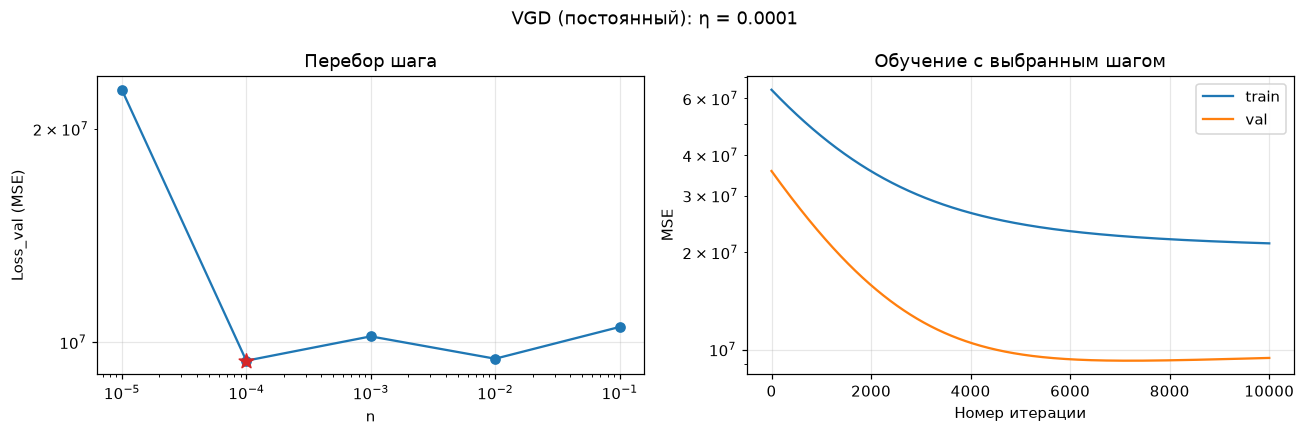

Остановка: лимит итераций. Запусков с численным переполнением: 1 из 6.


In [5]:
run_experiment(VanillaGradientDescent, 'constant', 'VGD (постоянный)')

5. Исследуйте VGD с переменным шагом n(lyamda) по формуле TimeDecayLR (из лекции):

переберите lyamda в логарифмической сетке от 10^-5 до 1

для каждого lyamda:

* обучите VGD на train
* найдите и запомните R^2_train и Loss_train
* протестируйте VGD на val, запомните Loss_val

найдите наилучший lyamda по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте VGD c n(best_lyamda) на test, запомните Loss_test, R^2_test, число итераций на test.

,λ,Loss_train,R²_train,Loss_val,Итерации,Остановка
0,1e-05,"63,388,248.02",0.00731,"35,407,811.01",10000,Лимит итераций
1,0.0001,"59,418,723.81",0.06948,"32,474,141.37",10000,Лимит итераций
2,0.001,"35,824,394.66",0.43897,"15,897,200.10",10000,Лимит итераций
3,0.01,"20,147,955.13",0.68447,"9,911,681.89",10000,Лимит итераций
4,0.1,"17,499,126.50",0.72596,"9,985,072.33",10000,Лимит итераций
5,1,"14,246,600.50",0.77689,"9,528,634.14",10000,Лимит итераций


Лучший шаг: η(k) = 1 / √(1 + k)
Loss_val выбранной модели: 9,528,634.14


,Метод,Лучший шаг,Loss_train,Loss_test,R²_train,R²_test,Число итераций на test
0,VGD (TimeDecayLR),η(k) = 1 / √(1 + k),"14,246,600.50","25,049,576.33",0.77689,0.61867,10000


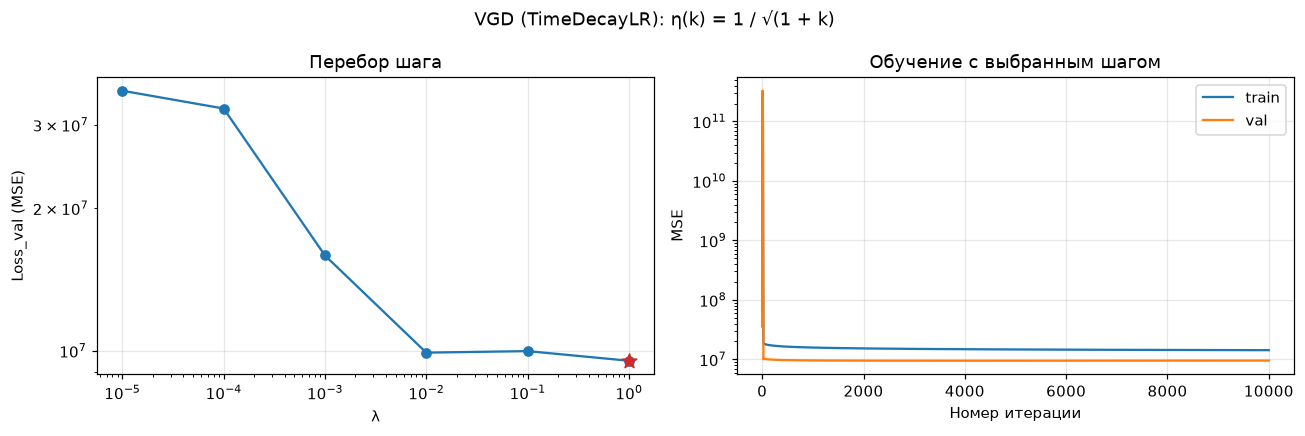

Остановка: лимит итераций. Запусков с численным переполнением: 0 из 6.


In [6]:
run_experiment(VanillaGradientDescent, 'decay', 'VGD (TimeDecayLR)')

6. Исследуйте SGD с постоянным шагом n:

переберите n в логарифмической сетке от 10^-5 до 1

для каждого n:

* обучите SGD на train
* найдите и запомните R^2_train и Loss_train
* протестируйте SGD на val, запомните Loss_val

найдите наилучший n по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте SGD c лучшим n на test, запомните Loss_test, R^2_test, число итераций на test.

,n,Loss_train,R²_train,Loss_val,Итерации,Остановка
0,1e-05,"45,940,683.62",0.28055,"22,757,299.53",10000,Лимит итераций
1,0.0001,"21,395,272.91",0.66494,"9,356,221.52",10000,Лимит итераций
2,0.001,"18,377,661.75",0.71220,"10,098,277.75",10000,Лимит итераций
3,0.01,"15,122,994.25",0.76317,"9,083,507.65",10000,Лимит итераций
4,0.1,"13,727,158.46",0.78503,"10,906,458.71",10000,Лимит итераций
5,1,inf,-inf,inf,199,Расходимость


Лучший шаг: η = 0.01
Loss_val выбранной модели: 9,083,507.65


,Метод,Лучший шаг,Loss_train,Loss_test,R²_train,R²_test,Число итераций на test
0,SGD (постоянный),η = 0.01,"15,122,994.25","25,738,128.09",0.76317,0.60819,10000


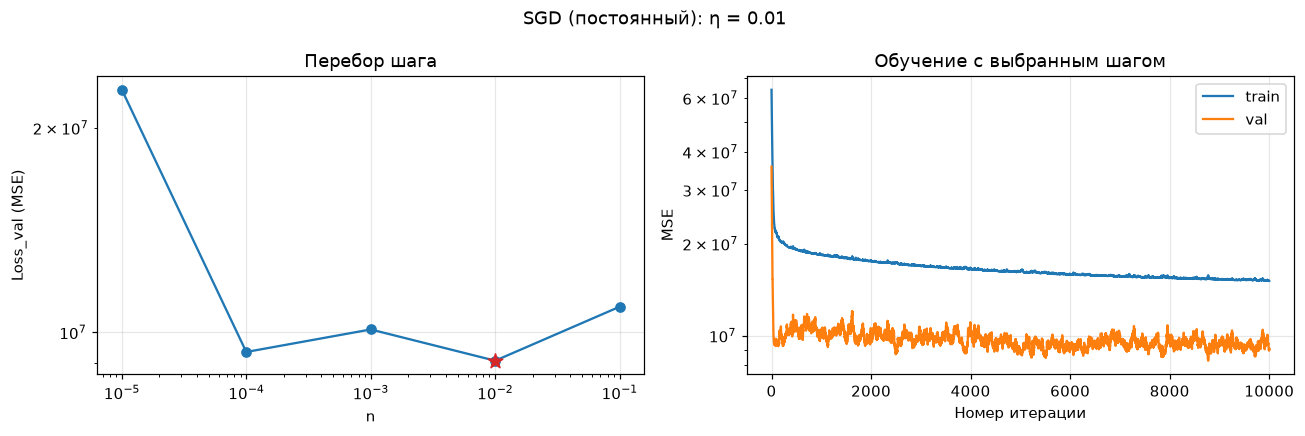

Остановка: лимит итераций. Запусков с численным переполнением: 1 из 6.


In [7]:
run_experiment(StochasticGradientDescent, 'constant', 'SGD (постоянный)')

7. Исследуйте SGD с переменным шагом n(lyamda) по формуле TimeDecayLR (из лекции):

переберите lyamda в логарифмической сетке от 10^-5 до 1

для каждого lyamda:

* обучите SGD на train
* найдите и запомните R^2_train и Loss_train
* протестируйте SGD на val, запомните Loss_val

найдите наилучший lyamda по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте SGD c n(best_lyamda) на test, запомните Loss_test, R^2_test, число итераций на test.

,λ,Loss_train,R²_train,Loss_val,Итерации,Остановка
0,1e-05,"63,389,325.55",0.00730,"35,408,739.82",10000,Лимит итераций
1,0.0001,"59,428,328.45",0.06933,"32,482,433.88",10000,Лимит итераций
2,0.001,"35,861,882.78",0.43839,"15,923,678.75",10000,Лимит итераций
3,0.01,"20,168,089.75",0.68416,"9,832,626.97",10000,Лимит итераций
4,0.1,"17,505,872.58",0.72585,"9,902,178.15",10000,Лимит итераций
5,1,"49,629,865.33",0.22277,"50,217,066.90",10000,Лимит итераций


Лучший шаг: η(k) = 0.01 / √(1 + k)
Loss_val выбранной модели: 9,832,626.97


,Метод,Лучший шаг,Loss_train,Loss_test,R²_train,R²_test,Число итераций на test
0,SGD (TimeDecayLR),η(k) = 0.01 / √(1 + k),"20,168,089.75","29,912,456.08",0.68416,0.54465,10000


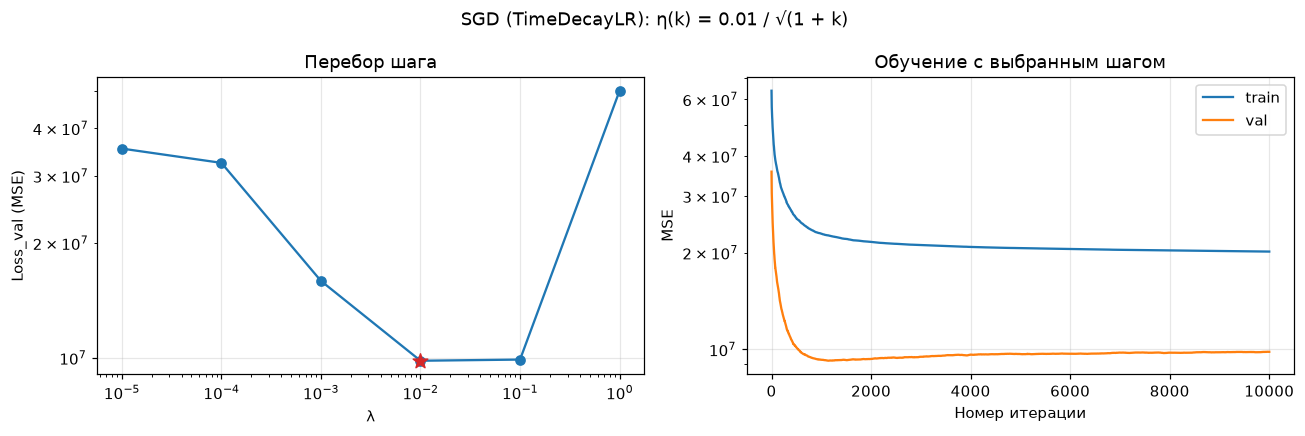

Остановка: лимит итераций. Запусков с численным переполнением: 0 из 6.


In [8]:
run_experiment(StochasticGradientDescent, 'decay', 'SGD (TimeDecayLR)')

8. Исследуйте SAG с постоянным шагом n:

переберите n в логарифмической сетке от 10^-5 до 1

для каждого n:

* обучите SAG на train
* найдите и запомните R^2_train и Loss_train
* протестируйте SAG на val, запомните Loss_val

найдите наилучший n по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте SAG c лучшим n на test, запомните Loss_test, R^2_test, число итераций на test.

,n,Loss_train,R²_train,Loss_val,Итерации,Остановка
0,1e-05,"46,560,270.44",0.27085,"23,178,418.56",10000,Лимит итераций
1,0.0001,"21,268,017.43",0.66693,"9,657,600.16",10000,Лимит итераций
2,0.001,"18,411,909.66",0.71166,"10,272,797.29",10000,Лимит итераций
3,0.01,"15,157,020.90",0.76263,"9,699,389.50",10000,Лимит итераций
4,0.1,1.147e+11,-1.795e+03,1.040e+11,10000,Лимит итераций
5,1,6.168e+61,-9.659e+53,5.008e+61,10000,Лимит итераций


Лучший шаг: η = 0.0001
Loss_val выбранной модели: 9,657,600.16


,Метод,Лучший шаг,Loss_train,Loss_test,R²_train,R²_test,Число итераций на test
0,SAG (постоянный),η = 0.0001,"21,268,017.43","30,930,204.09",0.66693,0.52915,10000


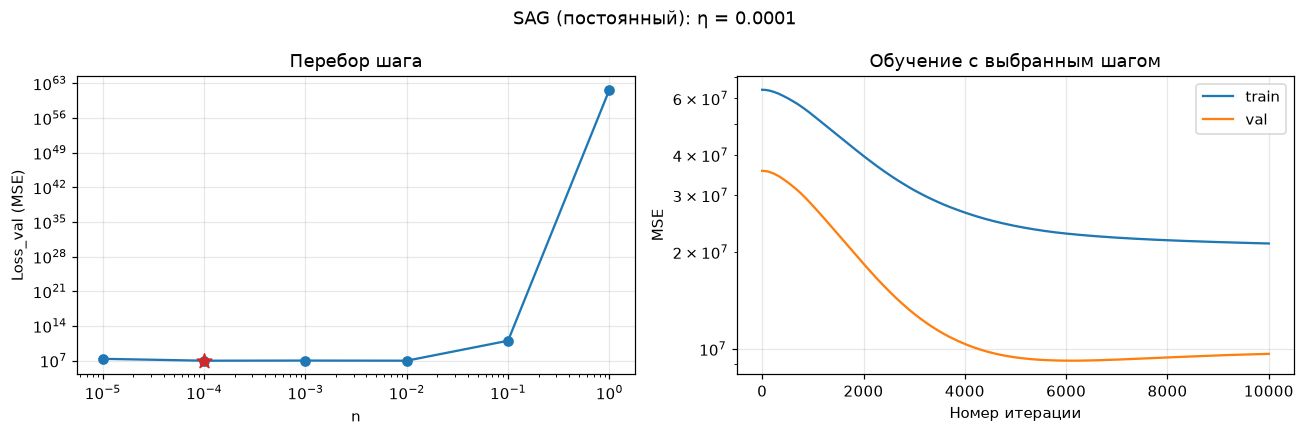

Остановка: лимит итераций. Запусков с численным переполнением: 0 из 6.


In [9]:
run_experiment(SAGDescent, 'constant', 'SAG (постоянный)')

9. Исследуйте SAG с переменным шагом n(lyamda) по формуле TimeDecayLR (из лекции):

переберите lyamda в логарифмической сетке от 10^-5 до 1

для каждого lyamda:

* обучите SAG на train
* найдите и запомните R^2_train и Loss_train
* протестируйте SAG на val, запомните Loss_val

найдите наилучший lyamda по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте SAG c n(best_lyamda) на test, запомните Loss_test, R^2_test, число итераций на test.

,λ,Loss_train,R²_train,Loss_val,Итерации,Остановка
0,1e-05,"63,492,026.49",0.00569,"35,484,255.42",10000,Лимит итераций
1,0.0001,"60,355,047.86",0.05481,"33,158,386.48",10000,Лимит итераций
2,0.001,"39,139,600.10",0.38706,"18,041,714.36",10000,Лимит итераций
3,0.01,"20,402,097.70",0.68049,"10,008,413.57",10000,Лимит итераций
4,0.1,"17,803,770.61",0.72119,"10,150,312.26",10000,Лимит итераций
5,1,"14,613,843.28",0.77114,"9,037,132.98",10000,Лимит итераций


Лучший шаг: η(k) = 1 / √(1 + k)
Loss_val выбранной модели: 9,037,132.98


,Метод,Лучший шаг,Loss_train,Loss_test,R²_train,R²_test,Число итераций на test
0,SAG (TimeDecayLR),η(k) = 1 / √(1 + k),"14,613,843.28","25,223,014.78",0.77114,0.61603,10000


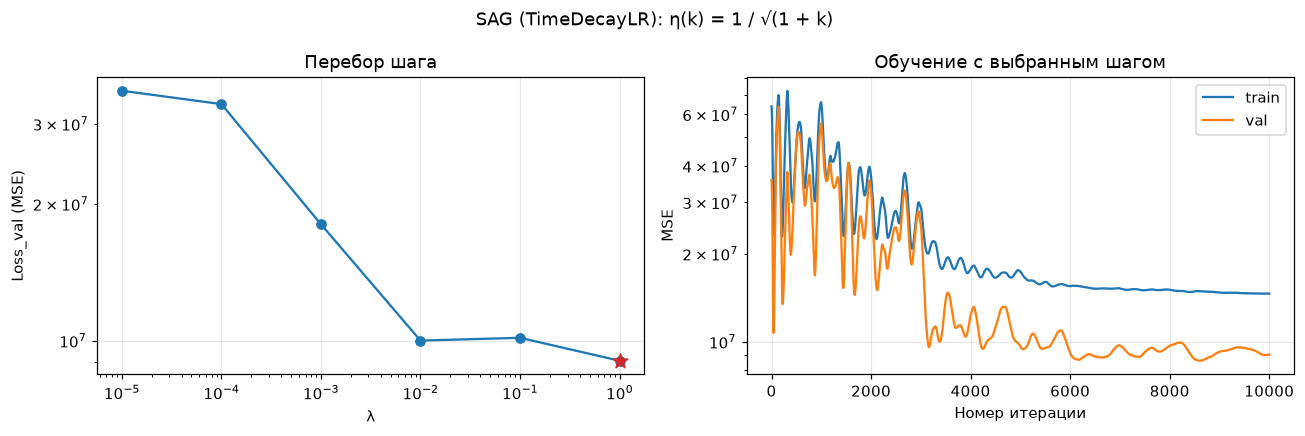

Остановка: лимит итераций. Запусков с численным переполнением: 0 из 6.


In [10]:
run_experiment(SAGDescent, 'decay', 'SAG (TimeDecayLR)')

10. Исследуйте Momentum с постоянным шагом n:

переберите n в логарифмической сетке от 10^-5 до 1

для каждого n:

* обучите Momentum на train
* найдите и запомните R^2_train и Loss_train
* протестируйте Momentum на val, запомните Loss_val

найдите наилучший n по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте Momentum c лучшим n на test, запомните Loss_test, R^2_test, число итераций на test.

,n,Loss_train,R²_train,Loss_val,Итерации,Остановка
0,1e-05,"21,335,428.59",0.66588,"9,418,368.33",10000,Лимит итераций
1,0.0001,"18,360,798.68",0.71246,"10,191,867.58",10000,Лимит итераций
2,0.001,"15,077,968.26",0.76387,"9,477,794.90",10000,Лимит итераций
3,0.01,"13,243,894.31",0.79259,"10,508,527.89",10000,Лимит итераций
4,0.1,"12,933,969.45",0.79745,"11,096,396.47",10000,Лимит итераций
5,1,inf,-inf,inf,226,Расходимость


Лучший шаг: η = 1e-05
Loss_val выбранной модели: 9,418,368.33


,Метод,Лучший шаг,Loss_train,Loss_test,R²_train,R²_test,Число итераций на test
0,Momentum (постоянный),η = 1e-05,"21,335,428.59","30,951,417.21",0.66588,0.52883,10000


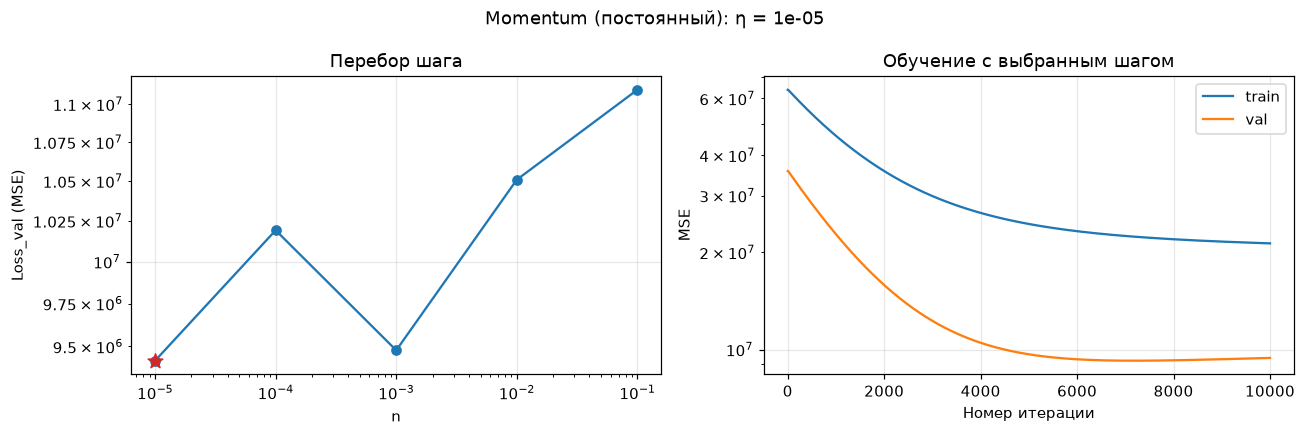

Остановка: лимит итераций. Запусков с численным переполнением: 1 из 6.


In [11]:
run_experiment(MomentumDescent, 'constant', 'Momentum (постоянный)')

11. Исследуйте Momentum с переменным шагом n(lyamda) по формуле TimeDecayLR (из лекции):

переберите lyamda в логарифмической сетке от 10^-5 до 1

для каждого lyamda:

* обучите Momentum на train
* найдите и запомните R^2_train и Loss_train
* протестируйте Momentum на val, запомните Loss_val

найдите наилучший lyamda по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте Momentum c n(best_lyamda) на test, запомните Loss_test, R^2_test, число итераций на test.

,λ,Loss_train,R²_train,Loss_val,Итерации,Остановка
0,1e-05,"59,420,178.26",0.06945,"32,475,203.44",10000,Лимит итераций
1,0.0001,"35,815,658.32",0.43911,"15,891,067.35",10000,Лимит итераций
2,0.001,"20,146,740.73",0.68449,"9,915,196.99",10000,Лимит итераций
3,0.01,"17,498,831.64",0.72596,"9,985,520.17",10000,Лимит итераций
4,0.1,"14,245,575.13",0.77691,"9,529,713.07",10000,Лимит итераций
5,1,"13,050,312.49",0.79563,"10,654,506.29",10000,Лимит итераций


Лучший шаг: η(k) = 0.1 / √(1 + k)
Loss_val выбранной модели: 9,529,713.07


,Метод,Лучший шаг,Loss_train,Loss_test,R²_train,R²_test,Число итераций на test
0,Momentum (TimeDecayLR),η(k) = 0.1 / √(1 + k),"14,245,575.13","25,048,145.82",0.77691,0.61869,10000


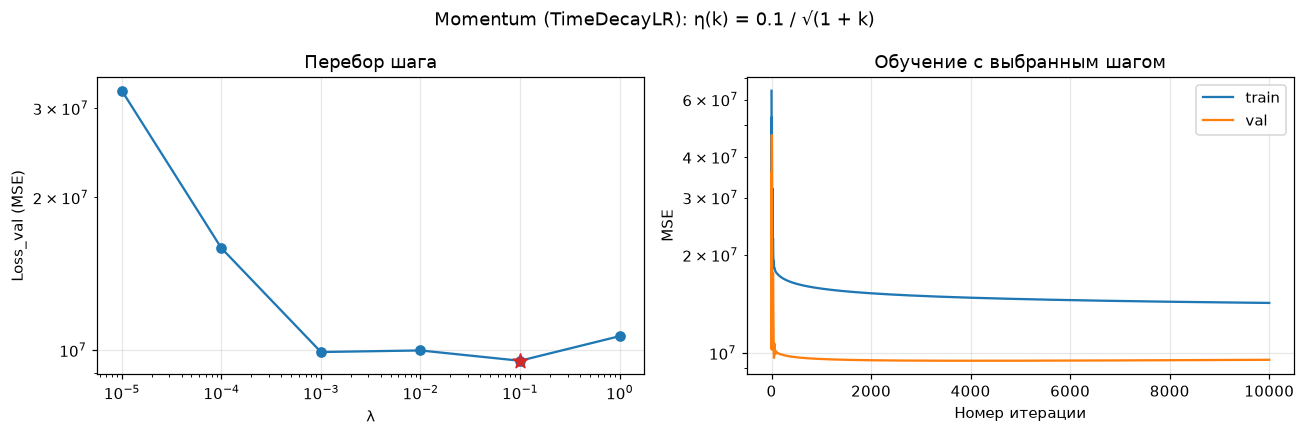

Остановка: лимит итераций. Запусков с численным переполнением: 0 из 6.


In [12]:
run_experiment(MomentumDescent, 'decay', 'Momentum (TimeDecayLR)')

12. Исследуйте Adam с постоянным шагом n:

переберите n в логарифмической сетке от 10^-5 до 1

для каждого n:

* обучите Adam на train
* найдите и запомните R^2_train и Loss_train
* протестируйте Adam на val, запомните Loss_val

найдите наилучший n по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте Adam c лучшим n на test, запомните Loss_test, R^2_test, число итераций на test.

,n,Loss_train,R²_train,Loss_val,Итерации,Остановка
0,1e-05,"35,154,490.27",0.44947,"15,002,665.12",10000,Лимит итераций
1,0.0001,"13,563,462.10",0.78759,"9,493,460.67",10000,Лимит итераций
2,0.001,"12,933,313.91",0.79746,"11,386,456.36",7515,Сходимость
3,0.01,"12,933,314.03",0.79746,"11,489,484.00",1863,Сходимость
4,0.1,"12,933,310.63",0.79746,"11,722,084.81",437,Сходимость
5,1,"12,933,312.91",0.79746,"11,574,427.79",273,Сходимость


Лучший шаг: η = 0.0001
Loss_val выбранной модели: 9,493,460.67


,Метод,Лучший шаг,Loss_train,Loss_test,R²_train,R²_test,Число итераций на test
0,Adam (постоянный),η = 0.0001,"13,563,462.10","23,474,749.67",0.78759,0.64265,10000


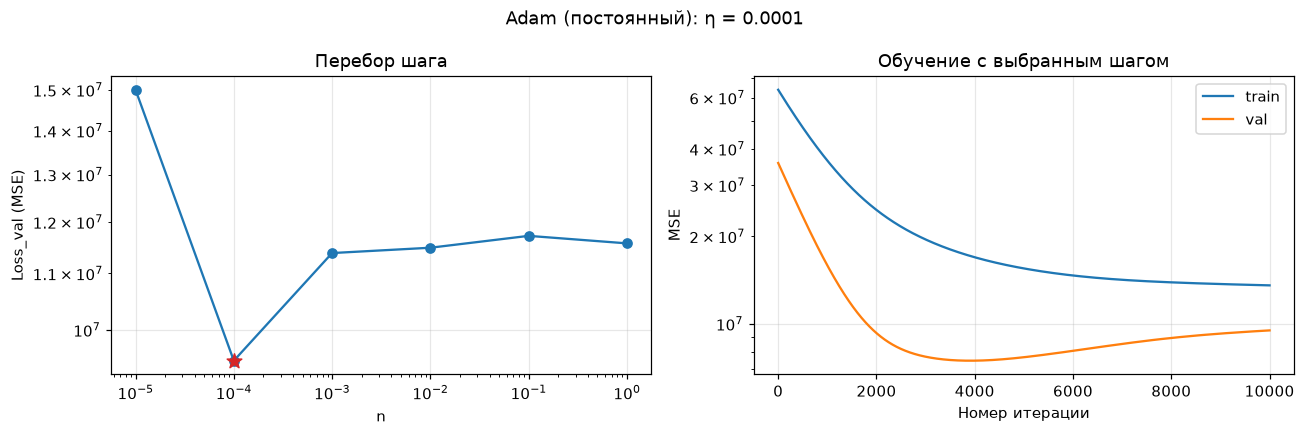

Остановка: лимит итераций. Запусков с численным переполнением: 0 из 6.


In [13]:
run_experiment(Adam, 'constant', 'Adam (постоянный)')

13. Исследуйте Adam с переменным шагом n(lyamda) по формуле TimeDecayLR (из лекции):

переберите lyamda в логарифмической сетке от 10^-5 до 1

для каждого lyamda:

* обучите Adam на train
* найдите и запомните R^2_train и Loss_train
* протестируйте Adam на val, запомните Loss_val

найдите наилучший lyamda по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте Adam c n(best_lyamda) на test, запомните Loss_test, R^2_test, число итераций на test.

,λ,Loss_train,R²_train,Loss_val,Итерации,Остановка
0,1e-05,"63,067,263.85",0.01234,"35,144,785.93",10000,Лимит итераций
1,0.0001,"56,397,476.64",0.11679,"30,074,511.09",10000,Лимит итераций
2,0.001,"22,865,843.71",0.64191,"8,862,302.87",10000,Лимит итераций
3,0.01,"12,998,452.23",0.79644,"11,106,964.08",10000,Лимит итераций
4,0.1,"12,933,313.89",0.79746,"11,799,886.53",3134,Сходимость
5,1,"12,933,313.04",0.79746,"11,655,279.46",2106,Сходимость


Лучший шаг: η(k) = 0.001 / √(1 + k)
Loss_val выбранной модели: 8,862,302.87


,Метод,Лучший шаг,Loss_train,Loss_test,R²_train,R²_test,Число итераций на test
0,Adam (TimeDecayLR),η(k) = 0.001 / √(1 + k),"22,865,843.71","31,840,043.50",0.64191,0.51530,10000


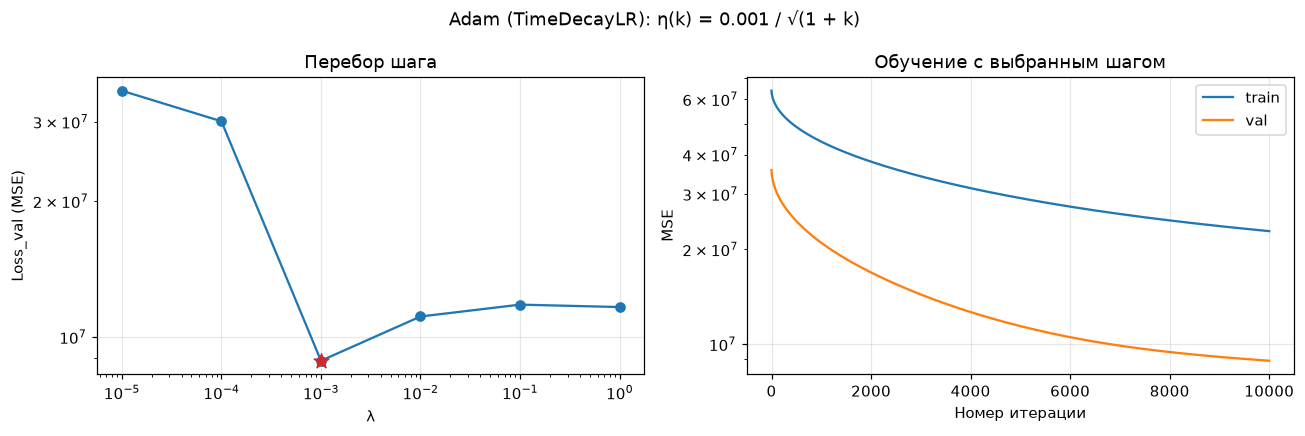

Остановка: лимит итераций. Запусков с численным переполнением: 0 из 6.


In [14]:
run_experiment(Adam, 'decay', 'Adam (TimeDecayLR)')

14. Постройте итоговую сравнительную таблицу со следующими столбцами:

1) название метода

2) значение лучшего шага (если n) или функция лучшего шага (если n(lyamda))

3) Loss_train

4) Loss_test

5) R^2 train

6) R^2 test

7) число итераций на test

,Метод,Лучший шаг,Loss_train,Loss_test,R²_train,R²_test,Число итераций на test
0,VGD (постоянный),η = 0.0001,"21,335,919.36","30,951,547.81",0.66587,0.52883,10000
1,VGD (TimeDecayLR),η(k) = 1 / √(1 + k),"14,246,600.50","25,049,576.33",0.77689,0.61867,10000
2,SGD (постоянный),η = 0.01,"15,122,994.25","25,738,128.09",0.76317,0.60819,10000
3,SGD (TimeDecayLR),η(k) = 0.01 / √(1 + k),"20,168,089.75","29,912,456.08",0.68416,0.54465,10000
4,SAG (постоянный),η = 0.0001,"21,268,017.43","30,930,204.09",0.66693,0.52915,10000
5,SAG (TimeDecayLR),η(k) = 1 / √(1 + k),"14,613,843.28","25,223,014.78",0.77114,0.61603,10000
6,Momentum (постоянный),η = 1e-05,"21,335,428.59","30,951,417.21",0.66588,0.52883,10000
7,Momentum (TimeDecayLR),η(k) = 0.1 / √(1 + k),"14,245,575.13","25,048,145.82",0.77691,0.61869,10000
8,Adam (постоянный),η = 0.0001,"13,563,462.10","23,474,749.67",0.78759,0.64265,10000
9,Adam (TimeDecayLR),η(k) = 0.001 / √(1 + k),"22,865,843.71","31,840,043.50",0.64191,0.51530,10000


,Метод,Loss_val,Остановка
0,VGD (постоянный),"9,416,627.63",Лимит итераций
1,VGD (TimeDecayLR),"9,528,634.14",Лимит итераций
2,SGD (постоянный),"9,083,507.65",Лимит итераций
3,SGD (TimeDecayLR),"9,832,626.97",Лимит итераций
4,SAG (постоянный),"9,657,600.16",Лимит итераций
5,SAG (TimeDecayLR),"9,037,132.98",Лимит итераций
6,Momentum (постоянный),"9,418,368.33",Лимит итераций
7,Momentum (TimeDecayLR),"9,529,713.07",Лимит итераций
8,Adam (постоянный),"9,493,460.67",Лимит итераций
9,Adam (TimeDecayLR),"8,862,302.87",Лимит итераций


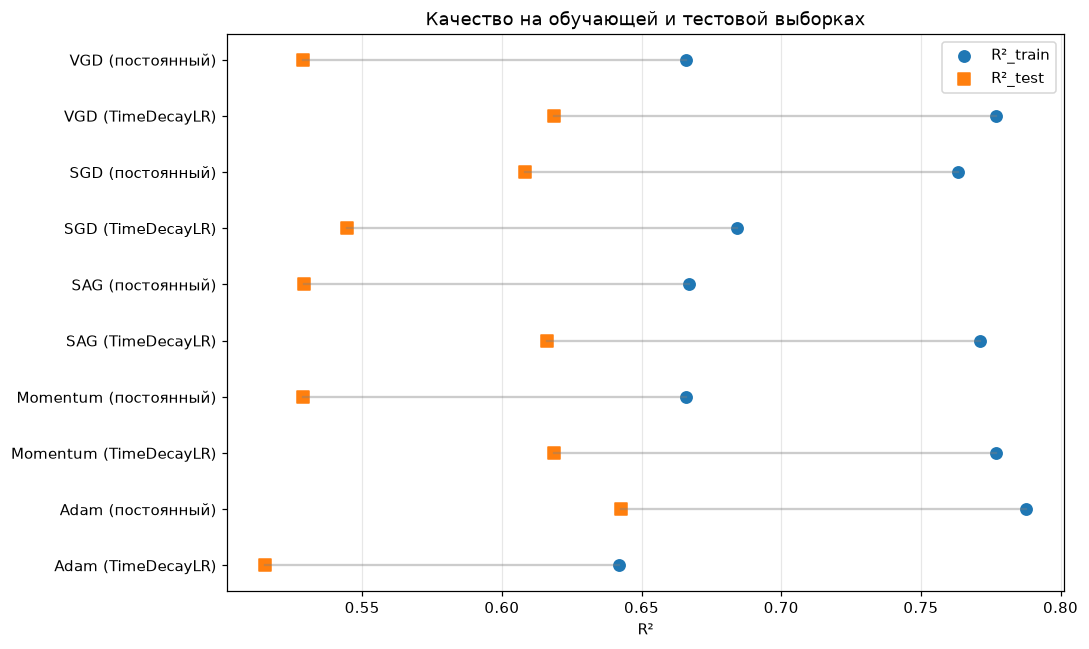

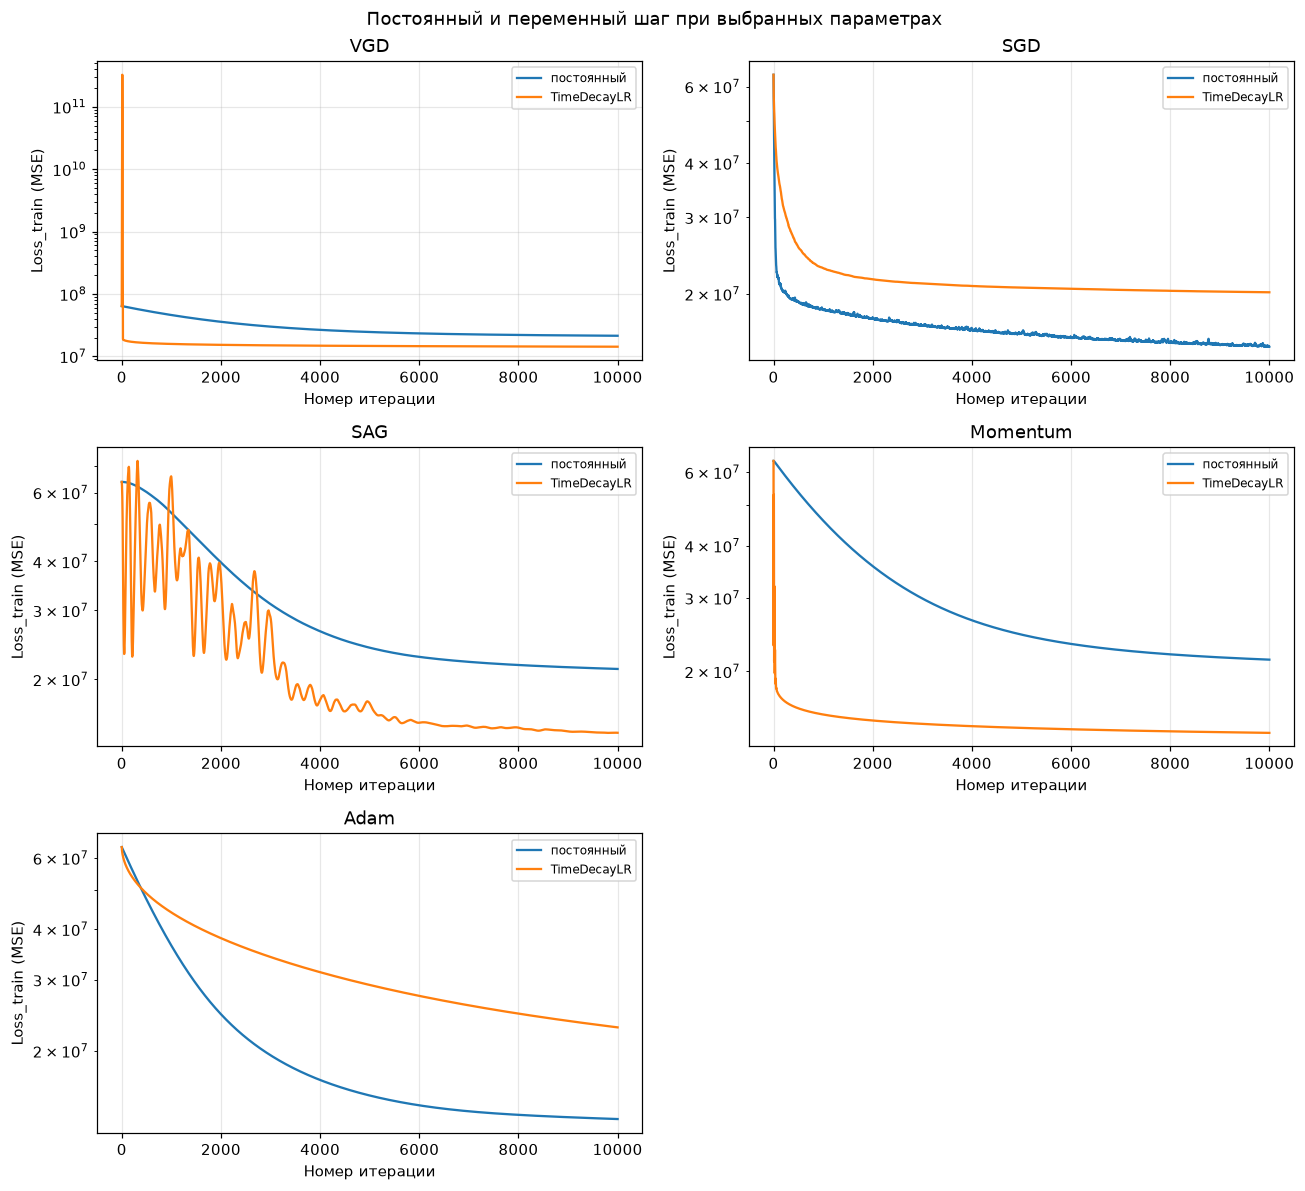

In [15]:
comparison = pd.DataFrame([experiment['result'] for experiment in experiments.values()])
display(metric_style(comparison))

selected_validation = pd.DataFrame([
    {'Метод': name, 'Loss_val': experiment['Loss_val'],
     'Остановка': experiment['model'].status}
    for name, experiment in experiments.items()
])
display(metric_style(selected_validation))

fig, ax = plt.subplots(figsize=(10, 6))
positions = np.arange(len(comparison))
ax.scatter(comparison['R²_train'], positions, label='R²_train', marker='o', s=55)
ax.scatter(comparison['R²_test'], positions, label='R²_test', marker='s', s=55)
for i, row in comparison.iterrows():
    ax.plot([row['R²_train'], row['R²_test']], [i, i], color='gray', alpha=0.4)
ax.set(yticks=positions, yticklabels=comparison['Метод'], xlabel='R²',
       title='Качество на обучающей и тестовой выборках')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 2, figsize=(12, 11))
for ax, method in zip(axes.flat, ['VGD', 'SGD', 'SAG', 'Momentum', 'Adam']):
    for label in ['постоянный', 'TimeDecayLR']:
        model = experiments[f'{method} ({label})']['model']
        ax.plot(np.arange(len(model.train_history)), model.train_history, label=label)
    ax.set(title=method, xlabel='Номер итерации', ylabel='Loss_train (MSE)', yscale='log')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
axes.flat[-1].set_visible(False)
fig.suptitle('Постоянный и переменный шаг при выбранных параметрах')
fig.tight_layout()
plt.show()

#### Дополнительная проверка результатов

Пересчитал MSE и R² напрямую по формулам и сравнил с функциями sklearn. Ещё нашёл решение методом наименьших квадратов: его ошибка на train служит нижней границей для тех же признаков. В итоговое сравнение десяти вариантов этот отдельный расчёт не включал.

Для SGD и SAG дополнительно повторил обучение с выбранными шагами при нескольких seed. Здесь смотрю только на train и val. Шаги и модели в основной таблице после этой проверки не меняю.

In [16]:
def manual_metrics(actual, predicted):
    residual = predicted - actual
    mse = np.dot(residual, residual) / len(actual)
    centered = actual - actual.mean()
    r2 = 1 - np.dot(residual, residual) / np.dot(centered, centered)
    return mse, r2


with threadpool_limits(limits=1):
    least_squares_weights = np.linalg.lstsq(X_train, y_train_scaled, rcond=None)[0]
least_squares_prediction = (X_train @ least_squares_weights) * y_scale + y_mean
least_squares_mse = mean_squared_error(y_train, least_squares_prediction)

for name, experiment in experiments.items():
    model = experiment['model']
    result = experiment['result']
    for matrix, actual, suffix in [(X_train, y_train, 'train'), (X_test, y_test, 'test')]:
        prediction = predict_price(model, matrix)
        mse, r2 = manual_metrics(actual, prediction)
        np.testing.assert_allclose(mse, result[f'Loss_{suffix}'], rtol=1e-12)
        np.testing.assert_allclose(r2, result[f'R²_{suffix}'], rtol=1e-12, atol=1e-12)
        np.testing.assert_allclose(r2, 1 - mse / np.var(actual), rtol=1e-12, atol=1e-12)
    assert result['Loss_train'] >= least_squares_mse - 1e-5
    assert len(model.train_history) == len(model.val_history) == model.n_iter + 1
    np.testing.assert_allclose(model.train_history[-1], result['Loss_train'], rtol=1e-12)
    np.testing.assert_allclose(model.val_history[-1], experiment['Loss_val'], rtol=1e-12)
    search = experiment['search']
    assert search.loc[experiment['best_index'], 'Loss_val'] == search['Loss_val'].min()

print('MSE и R² совпали с прямым расчётом для всех десяти моделей.')
print('Последние точки графиков совпали с метриками в таблицах.')
print(f'Минимальная MSE на train по МНК: {least_squares_mse:,.2f}')
print(f'Лучшая MSE на train среди десяти вариантов: {comparison["Loss_train"].min():,.2f}')

seed_rows = []
with threadpool_limits(limits=1):
    for name, experiment in experiments.items():
        if experiment['method'] not in (StochasticGradientDescent, SAGDescent):
            continue
        for seed in [0, 1, 2, 42, 99]:
            if seed == 42:
                model = experiment['model']
            else:
                model = experiment['method'](lyamda=experiment['model'].lyamda,
                    schedule=experiment['schedule'], random_state=seed)
                model.fit(X_train, y_train_scaled, X_val, y_val_scaled, loss_scale=y_scale ** 2)
            seed_rows.append({'Метод': name, 'seed': seed,
                'Loss_train': model.train_history[-1], 'Loss_val': model.val_history[-1],
                'Остановка': model.status})

seed_results = pd.DataFrame(seed_rows)
seed_summary = seed_results.groupby('Метод', sort=False).agg(
    Запусков=('seed', 'size'),
    Средняя_Loss_val=('Loss_val', 'mean'),
    Стандартное_отклонение=('Loss_val', 'std'),
    Минимальная_Loss_val=('Loss_val', 'min'),
    Максимальная_Loss_val=('Loss_val', 'max')
)
display(seed_summary.style.format({c: '{:,.2f}' for c in seed_summary.columns if c != 'Запусков'}))

MSE и R² совпали с прямым расчётом для всех десяти моделей.
Последние точки графиков совпали с метриками в таблицах.
Минимальная MSE на train по МНК: 12,933,310.59
Лучшая MSE на train среди десяти вариантов: 13,563,462.10


,Запусков,Средняя_Loss_val,Стандартное_отклонение,Минимальная_Loss_val,Максимальная_Loss_val
Метод,,,,,
SGD (постоянный),5,"9,431,649.10","608,981.16","9,083,507.65","10,508,636.23"
SGD (TimeDecayLR),5,"9,898,694.62","45,804.06","9,832,626.97","9,948,452.10"
SAG (постоянный),5,"9,649,914.29","14,749.87","9,635,271.29","9,671,035.09"
SAG (TimeDecayLR),5,"10,792,539.40","2,466,620.38","9,037,132.98","15,143,454.18"


15. Сделайте вывод о том, какой метод и шаг линейной регрессии самый лучший для данной выборки и ответьте на вопросы:

1) почему именно этот метод и этот шаг самый лучший (по каким данным из таблицы вы сделали такой вывод)

2) расскажите простыми словами суть R^2_train и R^2_test?

3) как R^2_train и R^2_test помогают сравнивать методы? почему оба эти значения надо вычислять для данного выбора?

In [17]:
ranking = comparison.sort_values('Loss_test').reset_index(drop=True)
winner, runner_up = ranking.iloc[0], ranking.iloc[1]
validation_winner = selected_validation.loc[selected_validation['Loss_val'].idxmin()]
best_training = comparison.loc[comparison['R²_train'].idxmax()]
sensitivity_name = seed_summary['Стандартное_отклонение'].idxmax()
sensitivity = seed_summary.loc[sensitivity_name]
relative_difference = 100 * (runner_up['Loss_test'] - winner['Loss_test']) / runner_up['Loss_test']
winner_model = experiments[winner['Метод']]['model']
baseline_prediction = np.full_like(y_test, y_train.mean())
baseline_mse = mean_squared_error(y_test, baseline_prediction)
baseline_r2 = r2_score(y_test, baseline_prediction)

display(Markdown(f"""
### 1. Какой метод выбрал и почему

У меня на тесте лучше всего получился **{winner['Метод']}**, шаг **{winner['Лучший шаг']}**.
Смотрел на Loss_test и R²_test: ошибка у него самая маленькая, **{winner['Loss_test']:,.2f}**,
а R² самый высокий, **{winner['R²_test']:.4f}**. То есть первое место выбрал по результату
на отложенных данных. Если взять корень из MSE, получится RMSE примерно
{np.sqrt(winner['Loss_test']):,.0f} в единицах цены. По этому числу уже проще понять размер ошибки.

Следом идёт {runner_up['Метод']} с шагом {runner_up['Лучший шаг']}.
У него Loss_test = {runner_up['Loss_test']:,.2f}, R²_test = {runner_up['R²_test']:.4f}.
У первого варианта тестовая ошибка примерно на {relative_difference:.2f}% меньше.
Но это результат на конкретных 100 автомобилях из test. На другом разбиении первое место может измениться.

Сами шаги я подбирал по val, тестовый набор для этого не использовал.
Причём на val лучше оказался другой вариант: **{validation_winner['Метод']}**,
**{experiments[validation_winner['Метод']]['result']['Лучший шаг']}**,
с ошибкой {validation_winner['Loss_val']:,.2f}. Если бы нужно было выбрать модель заранее,
ещё до просмотра test, я бы взял именно его. Здесь же в задании сравниваю уже полученные
тестовые результаты. После этого шаги не подгонял.

У лучшего на тесте варианта прошло {int(winner['Число итераций на test'])} итераций,
остановка — {winner_model.status.lower()}. То есть обучение упёрлось в заданный лимит.
Это ещё не значит, что веса окончательно сошлись. На самом тесте итераций обучения нет,
там я только считал прогнозы.

Переменный шаг не везде оказался лучше постоянного. Он уменьшается по ходу обучения,
и при слишком маленьком λ модель может просто не успеть нормально обучиться за 10000 шагов.
Слишком большой постоянный шаг тоже не подходит: ошибка может начать расти.
По времени методы я не сравнивал. У SGD и SAG само обновление использует меньше объектов,
но в моём коде после каждого шага ещё считаются полные ошибки и градиент для проверки остановки.

Ещё проверил, что будет при других seed. Сильнее всего менялся {sensitivity_name}:
Loss_val была от {sensitivity['Минимальная_Loss_val'] / 1e6:.2f} до
{sensitivity['Максимальная_Loss_val'] / 1e6:.2f} млн. Разница заметная, поэтому одного
удачного запуска случайного метода мало для общего вывода. В основной таблице везде оставил seed = 42.

### 2. Что такое R²_train и R²_test простыми словами

Можно вообще не строить модель, а каждый раз выдавать среднюю цену автомобиля.
R² показывает, насколько прогноз модели лучше такого простого варианта.
Он считается по формуле R² = 1 − SSE / SST. SSE — сумма квадратов ошибок модели,
SST — сумма квадратов отклонений реальных цен от среднего по той выборке, которую проверяем.

R²_train считаю на обучающей выборке, которую модель уже видела.
R²_test — на тестовой, которая в обучение не попадала.
При R² = 1 все цены предсказаны точно. При R² = 0 ошибка такая же, как у прогноза средним.
Если R² отрицательный, модель справилась даже хуже этого простого прогноза.

У лучшего варианта R²_test = {winner['R²_test']:.4f}. Получается, он объясняет примерно
{winner['R²_test'] * 100:.2f}% разброса цен в тестовом наборе. Это не значит, что он точно
угадал цену у {winner['R²_test'] * 100:.0f}% автомобилей.

Для сравнения я отдельно предсказал всем тестовым автомобилям среднюю цену из train.
Получил MSE = {baseline_mse:,.2f} и R² = {baseline_r2:.4f}.
Небольшой минус здесь нормален: средняя цена в train не совсем совпадает со средней в test,
а в формуле R² для теста используется именно среднее по test.

### 3. Зачем считать оба R² и как по ним сравнивать методы

На одной тестовой выборке чем выше R²_test, тем лучше результат. Порядок методов будет
таким же, как при сравнении MSE: меньшая ошибка даёт больший R².
Это видно из формулы R² = 1 − MSE / Var(y), если дисперсию считать с делением на число объектов.
На разных выборках такая связь для сравнения уже не подходит: разброс цен у них может отличаться.

R²_train нужен, чтобы понять, как модель справилась с обучающими данными.
Но одного этого числа мало. Можно хорошо подстроиться под train и хуже предсказывать цены
на новых автомобилях. Если R²_train высокий, а R²_test сильно ниже, стоит проверить переобучение.
Правда, разница может быть и из-за самого разбиения или отдельных дорогих машин в тесте.
Если оба показателя низкие, возможно, модель недообучилась или ей не хватает подходящих признаков.

В моей таблице на первом месте и по train, и по test оказался {best_training['Метод']}.
На обучении у него R² = {best_training['R²_train']:.4f}, а на тесте — {best_training['R²_test']:.4f}.
Если бы я посмотрел только на train, оценка качества получилась бы завышенной.
Поэтому нужны оба числа: одно показывает результат на знакомых данных, второе — на отложенных.
Сам R² веса не меняет, во всех этих методах я минимизирую MSE.
"""))


### 1. Какой метод выбрал и почему

У меня на тесте лучше всего получился **Adam (постоянный)**, шаг **η = 0.0001**.
Смотрел на Loss_test и R²_test: ошибка у него самая маленькая, **23,474,749.67**,
а R² самый высокий, **0.6426**. То есть первое место выбрал по результату
на отложенных данных. Если взять корень из MSE, получится RMSE примерно
4,845 в единицах цены. По этому числу уже проще понять размер ошибки.

Следом идёт Momentum (TimeDecayLR) с шагом η(k) = 0.1 / √(1 + k).
У него Loss_test = 25,048,145.82, R²_test = 0.6187.
У первого варианта тестовая ошибка примерно на 6.28% меньше.
Но это результат на конкретных 100 автомобилях из test. На другом разбиении первое место может измениться.

Сами шаги я подбирал по val, тестовый набор для этого не использовал.
Причём на val лучше оказался другой вариант: **Adam (TimeDecayLR)**,
**η(k) = 0.001 / √(1 + k)**,
с ошибкой 8,862,302.87. Если бы нужно было выбрать модель заранее,
ещё до просмотра test, я бы взял именно его. Здесь же в задании сравниваю уже полученные
тестовые результаты. После этого шаги не подгонял.

У лучшего на тесте варианта прошло 10000 итераций,
остановка — лимит итераций. То есть обучение упёрлось в заданный лимит.
Это ещё не значит, что веса окончательно сошлись. На самом тесте итераций обучения нет,
там я только считал прогнозы.

Переменный шаг не везде оказался лучше постоянного. Он уменьшается по ходу обучения,
и при слишком маленьком λ модель может просто не успеть нормально обучиться за 10000 шагов.
Слишком большой постоянный шаг тоже не подходит: ошибка может начать расти.
По времени методы я не сравнивал. У SGD и SAG само обновление использует меньше объектов,
но в моём коде после каждого шага ещё считаются полные ошибки и градиент для проверки остановки.

Ещё проверил, что будет при других seed. Сильнее всего менялся SAG (TimeDecayLR):
Loss_val была от 9.04 до
15.14 млн. Разница заметная, поэтому одного
удачного запуска случайного метода мало для общего вывода. В основной таблице везде оставил seed = 42.

### 2. Что такое R²_train и R²_test простыми словами

Можно вообще не строить модель, а каждый раз выдавать среднюю цену автомобиля.
R² показывает, насколько прогноз модели лучше такого простого варианта.
Он считается по формуле R² = 1 − SSE / SST. SSE — сумма квадратов ошибок модели,
SST — сумма квадратов отклонений реальных цен от среднего по той выборке, которую проверяем.

R²_train считаю на обучающей выборке, которую модель уже видела.
R²_test — на тестовой, которая в обучение не попадала.
При R² = 1 все цены предсказаны точно. При R² = 0 ошибка такая же, как у прогноза средним.
Если R² отрицательный, модель справилась даже хуже этого простого прогноза.

У лучшего варианта R²_test = 0.6426. Получается, он объясняет примерно
64.26% разброса цен в тестовом наборе. Это не значит, что он точно
угадал цену у 64% автомобилей.

Для сравнения я отдельно предсказал всем тестовым автомобилям среднюю цену из train.
Получил MSE = 66,002,014.09 и R² = -0.0047.
Небольшой минус здесь нормален: средняя цена в train не совсем совпадает со средней в test,
а в формуле R² для теста используется именно среднее по test.

### 3. Зачем считать оба R² и как по ним сравнивать методы

На одной тестовой выборке чем выше R²_test, тем лучше результат. Порядок методов будет
таким же, как при сравнении MSE: меньшая ошибка даёт больший R².
Это видно из формулы R² = 1 − MSE / Var(y), если дисперсию считать с делением на число объектов.
На разных выборках такая связь для сравнения уже не подходит: разброс цен у них может отличаться.

R²_train нужен, чтобы понять, как модель справилась с обучающими данными.
Но одного этого числа мало. Можно хорошо подстроиться под train и хуже предсказывать цены
на новых автомобилях. Если R²_train высокий, а R²_test сильно ниже, стоит проверить переобучение.
Правда, разница может быть и из-за самого разбиения или отдельных дорогих машин в тесте.
Если оба показателя низкие, возможно, модель недообучилась или ей не хватает подходящих признаков.

В моей таблице на первом месте и по train, и по test оказался Adam (постоянный).
На обучении у него R² = 0.7876, а на тесте — 0.6426.
Если бы я посмотрел только на train, оценка качества получилась бы завышенной.
Поэтому нужны оба числа: одно показывает результат на знакомых данных, второе — на отложенных.
Сам R² веса не меняет, во всех этих методах я минимизирую MSE.
